# Utforsk features og velg modellgrunnlag

Denne notebooken bruker feature-metadata aktivt for å hindre target leakage. Målet er å finne et robust første feature-sett for å predikere `target_points` i en kommende kamp.

**Viktig:** Vi bruker bare rader merket `SAFE` som modellfeatures. `UNSAFE_LEAKAGE` skal aldri inn i modellen, og `REVIEW` holdes utenfor til innsamlingstidspunktet er dokumentert. Valideringen deles kronologisk på sesong; tilfeldig train/test-splitt vil gi et for optimistisk bilde.

In [ ]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', 120)
sns.set_theme(style='whitegrid')

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
FEATURES_PATH = ROOT / 'data/processed/player_fixture_features.csv'
METADATA_PATH = ROOT / 'data/processed/feature_metadata.csv'
assert FEATURES_PATH.exists(), FEATURES_PATH
assert METADATA_PATH.exists(), METADATA_PATH
print('Prosjektrot:', ROOT)

Prosjektrot: /Users/henrik/Documents/fplmodell


In [ ]:
features = pd.read_csv(FEATURES_PATH, low_memory=False)
metadata = pd.read_csv(METADATA_PATH)
print(f'Features: {features.shape[0]:,} rader × {features.shape[1]:,} kolonner')
print(f'Metadata: {metadata.shape[0]:,} features')
display(features.head(3))
display(metadata.head(10))

Features: 254,441 rader × 503 kolonner
Metadata: 503 features


,name,assists,attempted_passes,big_chances_created,big_chances_missed,bonus,bps,clean_sheets,clearances_blocks_interceptions,completed_passes,creativity,dribbles,ea_index,player_id,errors_leading_to_goal,errors_leading_to_goal_attempt,fixture,fouls,goals_conceded,goals_scored,ict_index,id,influence,key_passes,kickoff_time,kickoff_time_formatted,loaned_in,loaned_out,minutes,offside,open_play_crosses,opponent_team,own_goals,penalties_conceded,penalties_missed,penalties_saved,recoveries,red_cards,round,saves,selected,tackled,tackles,target_missed,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,winning_goals,yellow_cards,GW,season,position,team,xP,...,defensive_contribution_rate3,clean_sheet_rate5,pass_completion_last5,defensive_contribution_rate5,clean_sheet_rate10,pass_completion_last10,defensive_contribution_rate10,team_games_played_before,team_points_last3,team_points_last5,team_points_last10,team_goals_scored_last3,team_goals_scored_last5,team_goals_scored_last10,team_goals_conceded_last3,team_goals_conceded_last5,team_goals_conceded_last10,team_goal_diff_last3,team_goal_diff_last5,team_goal_diff_last10,team_points_per_game_before,team_goals_for_per_game_before,team_goals_against_per_game_before,team_goal_difference_per_game_before,team_home_games_before,team_home_goals_for_pg_before,team_home_goals_against_pg_before,team_away_games_before,team_away_goals_for_pg_before,team_away_goals_against_pg_before,opp_games_played_before,opp_points_last3,opp_points_last5,opp_points_last10,opp_goals_scored_last3,opp_goals_scored_last5,opp_goals_scored_last10,opp_goals_conceded_last3,opp_goals_conceded_last5,opp_goals_conceded_last10,opp_goal_diff_last3,opp_goal_diff_last5,opp_goal_diff_last10,opp_points_per_game_before,opp_goals_for_per_game_before,opp_goals_against_per_game_before,opp_goal_difference_per_game_before,opp_home_games_before,opp_home_goals_for_pg_before,opp_home_goals_against_pg_before,opp_away_games_before,opp_away_goals_for_pg_before,opp_away_goals_against_pg_before,ppg_difference,goal_difference_per_game_difference,team_attack_vs_opp_defence,team_defence_vs_opp_attack,recent_form_difference_3,recent_form_difference_5,recent_goal_difference_5
0,David_Ospina,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,8,0.0,0,0,0.0,1.0,0.0,0.0,2016-08-14 15:00:00+00:00,14 Aug 16:00,0.0,0.0,0,0.0,0.0,9,0,0.0,0,0,0.0,0,1,0,6064,0.0,0.0,0.0,4.0,3.0,0.0,0,0,0,0,50,True,0.0,0,1,2016-17,NaN,Arsenal,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,David_Ospina,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,13,0.0,0,0,0.0,526.0,0.0,0.0,2016-08-20 16:30:00+00:00,20 Aug 17:30,0.0,0.0,0,0.0,0.0,8,0,0.0,0,0,0.0,0,2,0,7400,0.0,0.0,0.0,0.0,0.0,0.0,0,-578,153,731,50,False,0.0,0,2,2016-17,NaN,Arsenal,NaN,...,0.0,0.0,NaN,0.0,0.0,NaN,0.0,1,0.0,0.0,0.0,3.0,3.0,3.0,4.0,4.0,4.0,-1.0,-1.0,-1.0,0.0,3.0,4.0,-1.0,1,3.0,4.0,0,NaN,NaN,1,0.0,0.0,0.0,1.0,1.0,1.0,2.0,2.0,2.0,-1.0,-1.0,-1.0,0.0,1.0,2.0,-1.0,0,NaN,NaN,1,1.0,2.0,0.0,0.0,1.0,-3.0,0.0,0.0,0.0
2,David_Ospina,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,28,0.0,0,0,0.0,1066.0,0.0,0.0,2016-08-27 14:00:00+00:00,27 Aug 15:00,0.0,0.0,0,0.0,0.0,18,0,0.0,0,0,0.0,0,3,0,7708,0.0,0.0,0.0,3.0,1.0,0.0,0,-571,150,721,50,False,0.0,0,3,2016-17,NaN,Arsenal,NaN,...,0.0,0.0,NaN,0.0,0.0,NaN,0.0,2,1.0,1.0,1.0,3.0,3.0,3.0,4.0,4.0,4.0,-1.0,-1.0,-1.0,0.5,1.5,2.0,-0.5,1,3.0,4.0,1,0.0,0.0,2,1.0,1.0,1.0,2.0,2.0,2.0,3.0,3.0,3.0,-1.0,-1.0,-1.0,0.5,1.0,1.5,-0.5,1,1.0,2.0,1,1.0,1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0


,feature_name,source_column,feature_group,transformation,timing,safe_for_prediction,notes
0,name,name,identifier_metadata,raw/renamed,IDENTIFIER,REVIEW,"Use for grouping, joins, or reporting; not as ..."
1,assists,assists,current_fixture_outcome,raw,POST_MATCH,UNSAFE_LEAKAGE,Current fixture outcome; preserve but never us...
2,attempted_passes,attempted_passes,current_fixture_outcome,raw,POST_MATCH,UNSAFE_LEAKAGE,Current fixture outcome; preserve but never us...
3,big_chances_created,big_chances_created,current_fixture_outcome,raw,POST_MATCH,UNSAFE_LEAKAGE,Current fixture outcome; preserve but never us...
4,big_chances_missed,big_chances_missed,current_fixture_outcome,raw,POST_MATCH,UNSAFE_LEAKAGE,Current fixture outcome; preserve but never us...
5,bonus,bonus,current_fixture_outcome,raw,POST_MATCH,UNSAFE_LEAKAGE,Current fixture outcome; preserve but never us...
6,bps,bps,current_fixture_outcome,raw,POST_MATCH,UNSAFE_LEAKAGE,Current fixture outcome; preserve but never us...
7,clean_sheets,clean_sheets,current_fixture_outcome,raw,POST_MATCH,UNSAFE_LEAKAGE,Current fixture outcome; preserve but never us...
8,clearances_blocks_interceptions,clearances_blocks_interceptions,current_fixture_outcome,raw,POST_MATCH,UNSAFE_LEAKAGE,Current fixture outcome; preserve but never us...
9,completed_passes,completed_passes,current_fixture_outcome,raw,POST_MATCH,UNSAFE_LEAKAGE,Current fixture outcome; preserve but never us...


## 1. Forstå metadata og lekkasjerisiko

,safe_for_prediction,timing,antall
0,REVIEW,HISTORICAL_SHIFTED,24
1,REVIEW,IDENTIFIER,15
2,REVIEW,UNKNOWN,12
3,SAFE,HISTORICAL_SHIFTED,335
4,SAFE,PRE_MATCH,57
5,UNSAFE_LEAKAGE,POST_MATCH,59
6,UNSAFE_LEAKAGE,UNKNOWN,1


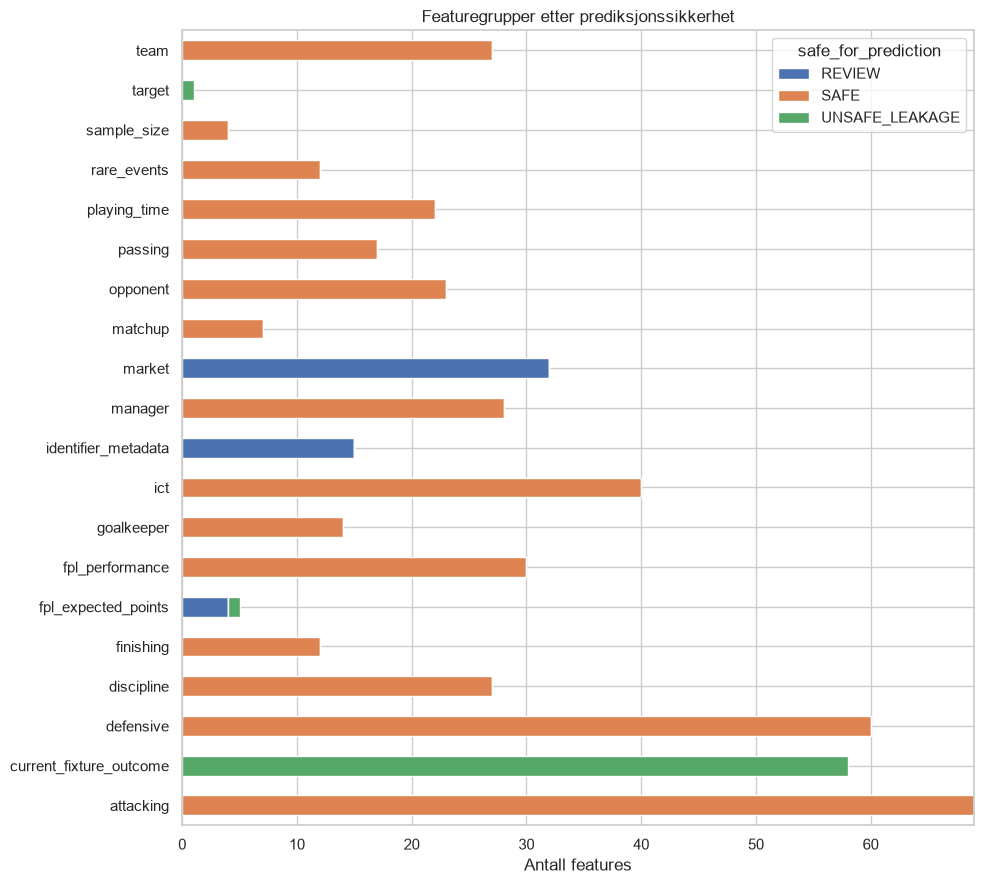

In [ ]:
summary = (metadata.groupby(['safe_for_prediction', 'timing'], dropna=False)
           .size().rename('antall').reset_index()
           .sort_values(['safe_for_prediction', 'antall'], ascending=[True, False]))
display(summary)
pd.crosstab(metadata.feature_group, metadata.safe_for_prediction).plot.barh(figsize=(10, 9), stacked=True)
plt.title('Featuregrupper etter prediksjonssikkerhet')
plt.xlabel('Antall features'); plt.ylabel(''); plt.tight_layout()

In [ ]:
TARGET = 'target_points'
safe_meta = metadata.loc[metadata.safe_for_prediction.eq('SAFE')].copy()
safe_features = [c for c in safe_meta.feature_name if c in features.columns and c != TARGET]
unsafe_present = [c for c in metadata.loc[metadata.safe_for_prediction.eq('UNSAFE_LEAKAGE'), 'feature_name'] if c in features]
review_present = [c for c in metadata.loc[metadata.safe_for_prediction.eq('REVIEW'), 'feature_name'] if c in features]
print(f'SAFE kandidater i data: {len(safe_features)}')
print(f'Blokkerte lekkasjefeatures: {len(unsafe_present)}')
print(f'REVIEW (ikke brukt automatisk): {len(review_present)}')
assert TARGET in features, f'Mangler målvariabelen {TARGET}'
assert not set(safe_features) & set(unsafe_present)
display(safe_meta.feature_group.value_counts().rename('antall_safe').to_frame())

SAFE kandidater i data: 392
Blokkerte lekkasjefeatures: 60
REVIEW (ikke brukt automatisk): 51


,antall_safe
feature_group,
attacking,69
defensive,60
ict,40
fpl_performance,30
manager,28
team,27
discipline,27
opponent,23
playing_time,22


## 2. Datadekning, målvariabel og tidsakse

,target_points
count,254441.000000
mean,1.253477
std,2.437701
min,-7.000000
1%,0.000000
5%,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
95%,7.000000


,size,count,mean,std
season,,,,
2016-17,23679,23679,1.314,2.481
2017-18,22467,22467,1.399,2.524
2018-19,21790,21790,1.424,2.564
2019-20,22501,22501,1.378,2.503
2020-21,24365,24365,1.291,2.472
2021-22,25447,25447,1.234,2.452
2022-23,26505,26505,1.197,2.355
2023-24,29725,29725,1.052,2.293
2024-25,27605,27605,1.201,2.417


,size,count,mean,std
position,,,,
AM,322,322,5.780,5.219
DEF,55121,55121,1.122,2.347
FWD,19847,19847,1.318,2.626
GK,18144,18144,0.880,2.069
GKP,101,101,0.713,1.538
MID,70469,70469,1.255,2.383
NaN,90437,90437,1.378,2.517


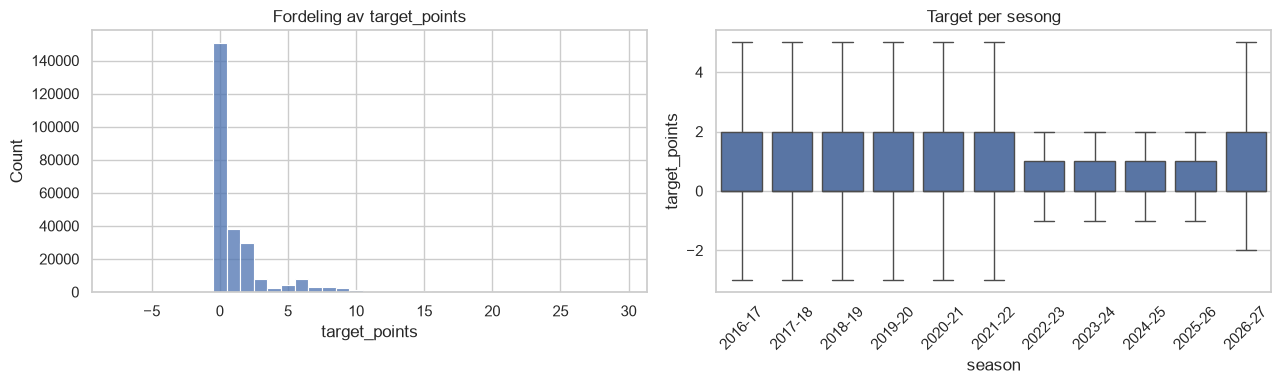

In [ ]:
display(features[TARGET].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).to_frame())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(features[TARGET].dropna(), discrete=True, ax=axes[0])
axes[0].set_title('Fordeling av target_points')
if 'season' in features:
    order = sorted(features.season.dropna().astype(str).unique())
    sns.boxplot(data=features, x='season', y=TARGET, order=order, showfliers=False, ax=axes[1])
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_title('Target per sesong')
plt.tight_layout()

for col in ['season', 'position']:
    if col in features:
        display(features.groupby(col, dropna=False)[TARGET].agg(['size','count','mean','std']).round(3))

In [ ]:
coverage = pd.DataFrame({
    'dtype': features[safe_features].dtypes.astype(str),
    'missing_pct': features[safe_features].isna().mean().mul(100),
    'n_unique': features[safe_features].nunique(dropna=True),
    'variance': features[safe_features].select_dtypes(include=np.number).var()
}).join(safe_meta.set_index('feature_name')[['feature_group','transformation','notes']])
coverage = coverage.sort_values(['missing_pct','n_unique'], ascending=[False, True])
display(coverage.head(40).round(3))
print('Helt tomme:', coverage.index[coverage.missing_pct.eq(100)].tolist())
print('Konstante:', coverage.index[coverage.n_unique.le(1)].tolist())

,dtype,missing_pct,n_unique,variance,feature_group,transformation,notes
mng_underdog_draw_last3,float64,95.039,3,0.005,manager,"shift(1), rolling(3).sum(min_periods=1)",NaN
mng_underdog_draw_last5,float64,95.039,3,0.009,manager,"shift(1), rolling(5).sum(min_periods=1)",NaN
mng_underdog_win_last3,float64,95.039,3,0.004,manager,"shift(1), rolling(3).sum(min_periods=1)",NaN
mng_underdog_win_last5,float64,95.039,3,0.007,manager,"shift(1), rolling(5).sum(min_periods=1)",NaN
mng_clean_sheets_last3,float64,95.039,4,0.025,manager,"shift(1), rolling(3).sum(min_periods=1)",NaN
mng_draw_last3,float64,95.039,4,0.020,manager,"shift(1), rolling(3).sum(min_periods=1)",NaN
mng_loss_last3,float64,95.039,4,0.047,manager,"shift(1), rolling(3).sum(min_periods=1)",NaN
mng_underdog_draw_last10,float64,95.039,4,0.016,manager,"shift(1), rolling(10).sum(min_periods=1)",NaN
mng_underdog_win_last10,float64,95.039,4,0.015,manager,"shift(1), rolling(10).sum(min_periods=1)",NaN
mng_win_last3,float64,95.039,4,0.049,manager,"shift(1), rolling(3).sum(min_periods=1)",NaN


Helt tomme: []
Konstante: ['loaned_in_last3', 'loaned_in_last5', 'loaned_in_last10', 'loaned_out_last3', 'loaned_out_last5', 'loaned_out_last10', 'loaned_in_season_before', 'loaned_out_season_before']


## 3. Kandidater, signal og redundans

Korrelasjon under er kun en enkel screening. Den kan overse ikke-lineære sammenhenger og må ikke brukes på hele datasettet for å velge features før sluttesten. Den er likevel nyttig for å oppdage dubletter og svært like 3/5/10-kampers vinduer.

,spearman_target,feature_group,missing_pct
minutes_avg3,0.691,playing_time,3.132
minutes_last3,0.687,playing_time,3.132
points_avg3,0.683,fpl_performance,3.132
ict_avg3,0.683,ict,3.132
points_avg5,0.681,fpl_performance,3.132
points_last3,0.681,fpl_performance,3.132
ict_last3,0.681,ict,3.132
minutes_avg5,0.680,playing_time,3.132
minutes_last1,0.679,playing_time,3.132
ict_avg5,0.677,ict,3.132


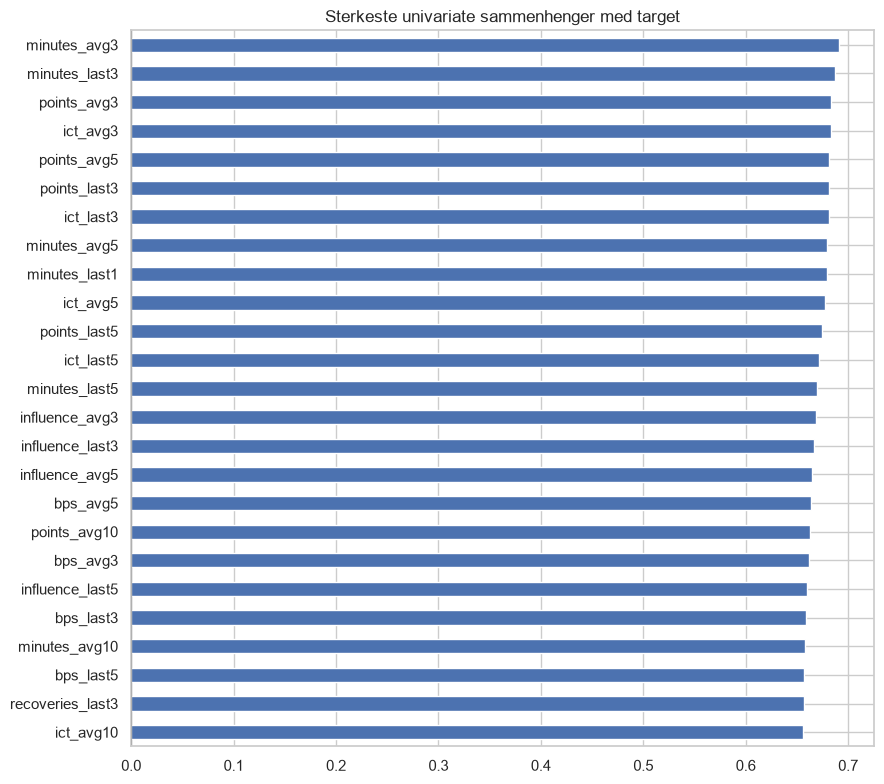

In [ ]:
numeric_safe = [c for c in safe_features if pd.api.types.is_numeric_dtype(features[c])]
# Et fast utvalg gjør rangkorrelasjon praktisk også på store datasett.
screening_data = features[numeric_safe + [TARGET]].sample(
    n=min(10_000, len(features)), random_state=42)
screening_corr = screening_data.corr(method='spearman')
corr_target = (screening_corr[TARGET]
               .drop(TARGET).dropna().sort_values(key=abs, ascending=False))
corr_table = corr_target.rename('spearman_target').to_frame().join(coverage[['feature_group','missing_pct']])
display(corr_table.head(40).round(3))
corr_table.head(25).sort_values('spearman_target').plot.barh(y='spearman_target', figsize=(9, 8), legend=False)
plt.axvline(0, color='black', lw=.8); plt.title('Sterkeste univariate sammenhenger med target')
plt.tight_layout()

In [ ]:
corr = screening_corr.loc[numeric_safe, numeric_safe].abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = (upper.stack().rename('abs_spearman').reset_index()
             .rename(columns={'level_0':'feature_1','level_1':'feature_2'})
             .query('abs_spearman >= 0.95').sort_values('abs_spearman', ascending=False))
display(high_corr.head(60).round(3))
print(f'{len(high_corr)} par har |Spearman| >= 0.95')

,feature_1,feature_2,abs_spearman
114364,mng_underdog_draw_last3,mng_underdog_draw_last5,1.000
112414,mng_goals_scored_season_before,mng_win_season_before,1.000
116722,mng_underdog_win_last10,mng_underdog_win_season_before,1.000
114757,mng_underdog_draw_last5,mng_underdog_draw_last10,1.000
114365,mng_underdog_draw_last3,mng_underdog_draw_last10,1.000
113578,mng_loss_last10,mng_loss_season_before,1.000
95893,saves_last3,saves_avg3,1.000
108862,mng_clean_sheets_last10,mng_clean_sheets_season_before,1.000
112006,mng_goals_scored_last10,mng_goals_scored_season_before,1.000
112022,mng_goals_scored_last10,mng_win_season_before,1.000


256 par har |Spearman| >= 0.95


## 4. Lag et konservativt første feature-sett

In [ ]:
# Fjern features som er ubrukelige uten å se på target. Behold NaN ellers; modellen kan imputere.
excluded_quality = set(coverage.index[(coverage.missing_pct >= 80) | (coverage.n_unique <= 1)])
candidates = [c for c in numeric_safe if c not in excluded_quality]

# Reduser svært korrelerte par deterministisk: minst missing først, deretter kortere navn.
ordered = sorted(candidates, key=lambda c: (coverage.loc[c, 'missing_pct'], len(c), c))
selected, dropped_redundant = [], []
for col in ordered:
    if any(corr.loc[col, kept] >= 0.98 for kept in selected):
        dropped_redundant.append(col)
    else:
        selected.append(col)

print(f'Numeriske SAFE: {len(numeric_safe)}')
print(f'Etter kvalitetsfilter: {len(candidates)}')
print(f'Etter redundansfilter: {len(selected)}')
display(pd.Series(selected, name='baseline_features').to_frame())

Numeriske SAFE: 392
Etter kvalitetsfilter: 333
Etter redundansfilter: 282


,baseline_features
0,xA_season_before
1,xG_season_before
2,CBI_season_before
3,bps_season_before
4,ict_season_before
...,...
277,xG90_last3
278,xGI90_last3
279,CBI90_last3
280,tackles90_last3


## 5. Tidsriktig baseline og feature-gruppe-ablation

Vi trener på alle tidligere sesonger og tester på siste sesong. `DummyRegressor` er minimumskravet. `HistGradientBoostingRegressor` gir en nyttig ikke-lineær tabulær baseline og håndterer manglende verdier. MAE er lett å tolke i FPL-poeng; RMSE straffer store bom mer.

> Featurevalg og hyperparametre bør senere gjøres med walk-forward-validering *innenfor treningsperioden*. Siste sesong bør forbli urørt som sluttest.

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

model_data = features.dropna(subset=[TARGET, 'season']).copy()
seasons = sorted(model_data.season.astype(str).unique())
assert len(seasons) >= 2, 'Trenger minst to sesonger for tidsbasert holdout'
season_counts = model_data.groupby(model_data.season.astype(str)).size()
eligible = season_counts[season_counts >= 5_000].index.tolist()
assert len(eligible) >= 2, 'Trenger minst to sesonger med minst 5 000 rader'
test_season = eligible[-1]  # hopper over en eventuell ufullstendig påbegynt sesong
train_mask = model_data.season.astype(str) < test_season
test_mask = model_data.season.astype(str).eq(test_season)
print('Trening:', sorted(model_data.loc[train_mask, 'season'].astype(str).unique()), int(train_mask.sum()), 'rader')
print('Test:', test_season, int(test_mask.sum()), 'rader')

def prepare_fold(train_frame, test_frame, cols):
    """Fjern kolonner som ikke kan binnes i akkurat denne treningsfolden."""
    if not cols:
        return train_frame.iloc[:, :0], test_frame.iloc[:, :0], []
    X_train = train_frame[cols].replace([np.inf, -np.inf], np.nan)
    X_test = test_frame[cols].replace([np.inf, -np.inf], np.nan)
    usable = [c for c in cols if X_train[c].notna().any() and X_train[c].nunique(dropna=True) > 1]
    return X_train[usable], X_test[usable], usable

def evaluate(cols, label):
    train_idx = model_data.index[train_mask]
    if len(train_idx) > 80_000:
        train_idx = model_data.loc[train_idx].sample(80_000, random_state=42).index
    y_train = model_data.loc[train_idx, TARGET]
    y_test = model_data.loc[test_mask, TARGET]
    X_train, X_test, usable = prepare_fold(
        model_data.loc[train_idx], model_data.loc[test_mask], cols)
    model = DummyRegressor(strategy='mean') if not usable else HistGradientBoostingRegressor(
        learning_rate=.07, max_iter=60, max_leaf_nodes=31, l2_regularization=1.0, random_state=42)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model.fit(X_train if usable else np.zeros((len(y_train), 1)), y_train)
        pred = model.predict(X_test if usable else np.zeros((len(y_test), 1)))
    return {'modell': label, 'n_features': len(usable), 'droppet_i_fold': len(cols) - len(usable),
            'MAE': mean_absolute_error(y_test, pred),
            'RMSE': mean_squared_error(y_test, pred) ** .5,
            'mean_prediction': pred.mean()}, model

results = [evaluate([], 'Dummy: treningsgjennomsnitt')[0]]
results.append(evaluate(selected, 'Alle valgte SAFE-features')[0])
largest_groups = safe_meta[safe_meta.feature_name.isin(selected)].feature_group.value_counts().head(4).index
for group, group_cols in safe_meta[safe_meta.feature_group.isin(largest_groups)].groupby('feature_group').feature_name:
    cols = [c for c in selected if c not in set(group_cols)]
    if cols and len(cols) < len(selected):
        results.append(evaluate(cols, f'Uten gruppe: {group}')[0])
results = pd.DataFrame(results).sort_values('MAE')
display(results.round(3))

Trening: ['2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25'] 224084 rader
Test: 2025-26 29747 rader


,modell,n_features,droppet_i_fold,MAE,RMSE,mean_prediction
3,Uten gruppe: defensive,234,0,0.986,1.933,1.090
2,Uten gruppe: attacking,221,4,0.987,1.937,1.091
5,Uten gruppe: team,254,4,0.988,1.936,1.097
1,Alle valgte SAFE-features,278,4,0.989,1.937,1.094
4,Uten gruppe: ict,249,4,0.997,1.935,1.124
0,Dummy: treningsgjennomsnitt,0,0,1.580,2.355,1.274


## 6. Walk-forward-test og automatisk beslutningsrapport

,validation_season,train_rows,n_features,droppet_i_fold,validation_rows,MAE,RMSE
0,2017-18,23679,237,45,22467,1.244,2.182
1,2018-19,46146,237,45,21790,1.259,2.196
2,2019-20,67936,237,45,22501,1.383,2.167
3,2020-21,80000,237,45,24365,1.150,2.098
4,2021-22,80000,237,45,25447,1.128,2.076
5,2022-23,80000,237,45,26505,1.051,1.965
6,2023-24,80000,272,10,29725,0.982,1.914
7,2024-25,80000,272,10,27605,1.073,2.067
8,2025-26,80000,278,4,29747,0.989,1.937


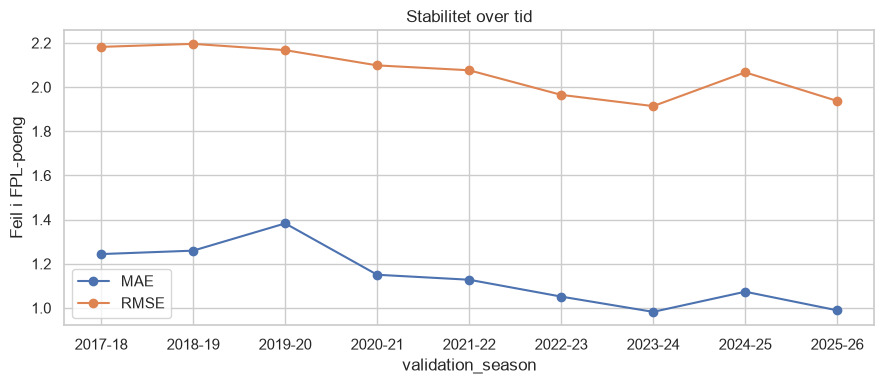

In [ ]:
folds = []
for validation_season in eligible[1:]:
    tr = model_data.season.astype(str) < validation_season
    va = model_data.season.astype(str).eq(validation_season)
    train_idx = model_data.index[tr]
    if len(train_idx) > 80_000:
        train_idx = model_data.loc[train_idx].sample(80_000, random_state=42).index
    ytr = model_data.loc[train_idx, TARGET]
    yva = model_data.loc[va, TARGET]
    Xtr, Xva, fold_features = prepare_fold(
        model_data.loc[train_idx], model_data.loc[va], selected)
    mdl = HistGradientBoostingRegressor(learning_rate=.07, max_iter=60, max_leaf_nodes=31,
                                        l2_regularization=1.0, random_state=42).fit(Xtr, ytr)
    pred = mdl.predict(Xva)
    folds.append({'validation_season': validation_season, 'train_rows': len(ytr),
                  'n_features': len(fold_features), 'droppet_i_fold': len(selected) - len(fold_features),
                  'validation_rows': len(yva), 'MAE': mean_absolute_error(yva, pred),
                  'RMSE': mean_squared_error(yva, pred) ** .5})
walk_forward = pd.DataFrame(folds)
display(walk_forward.round(3))
walk_forward.plot(x='validation_season', y=['MAE','RMSE'], marker='o', figsize=(9,4))
plt.title('Stabilitet over tid'); plt.ylabel('Feil i FPL-poeng'); plt.tight_layout()

In [ ]:
best = results.iloc[0]
recommendation = pd.DataFrame({
    'bruk': selected,
}).join(safe_meta.set_index('feature_name')[['feature_group','transformation']], on='bruk')
print('ANBEFALING')
print('1. Start med kun SAFE-features i tabellen under.')
print('2. Hold UNSAFE_LEAKAGE og REVIEW helt ute av første modell.')
print('3. Bruk sesongbasert walk-forward CV; aldri tilfeldig splitting av kamp-rader.')
print('4. Sammenlign alltid mot DummyRegressor og gjerne en enkel regularisert lineær modell.')
print('5. Velg/juster features på eldre folds; bruk siste sesong én gang som sluttest.')
print(f'Beste holdout-variant i denne kjøringen: {best.modell} (MAE={best.MAE:.3f}).')
display(recommendation.groupby('feature_group').size().rename('antall').to_frame())
display(recommendation)

# Kan brukes direkte av neste notebook/script:
MODEL_FEATURES = recommendation.bruk.tolist()
print('MODEL_FEATURES er nå tilgjengelig med', len(MODEL_FEATURES), 'kolonner.')

ANBEFALING
1. Start med kun SAFE-features i tabellen under.
2. Hold UNSAFE_LEAKAGE og REVIEW helt ute av første modell.
3. Bruk sesongbasert walk-forward CV; aldri tilfeldig splitting av kamp-rader.
4. Sammenlign alltid mot DummyRegressor og gjerne en enkel regularisert lineær modell.
5. Velg/juster features på eldre folds; bruk siste sesong én gang som sluttest.
Beste holdout-variant i denne kjøringen: Uten gruppe: defensive (MAE=0.986).


,antall
feature_group,
attacking,57
defensive,48
discipline,24
finishing,9
fpl_performance,20
goalkeeper,8
ict,29
manager,6
matchup,7


,bruk,feature_group,transformation
0,xA_season_before,attacking,"shift(1), season expanding sum"
1,xG_season_before,attacking,"shift(1), season expanding sum"
2,CBI_season_before,defensive,"shift(1), season expanding sum"
3,bps_season_before,fpl_performance,"shift(1), season expanding sum"
4,ict_season_before,ict,"shift(1), season expanding sum"
...,...,...,...
277,xG90_last3,attacking,90 * sum(prior 3 expected_goals) / sum(prior 3...
278,xGI90_last3,attacking,90 * sum(prior 3 expected_goal_involvements) /...
279,CBI90_last3,defensive,90 * sum(prior 3 clearances_blocks_interceptio...
280,tackles90_last3,defensive,90 * sum(prior 3 tackles) / sum(prior 3 minutes)


MODEL_FEATURES er nå tilgjengelig med 282 kolonner.
